First 10 Records:
    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   
5  699-14-3026      C  Naypyitaw        Normal            Male   
6  355-53-5943      A     Yangon        Member          Female   
7  315-22-5665      C  Naypyitaw        Normal          Female   
8  665-32-9167      A     Yangon        Member          Female   
9  692-92-5582      B   Mandalay        Member          Female   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33

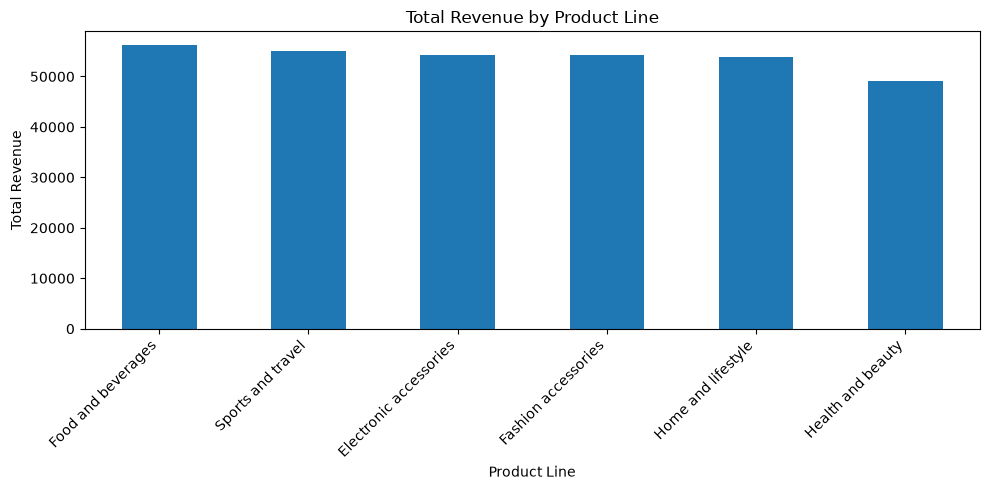

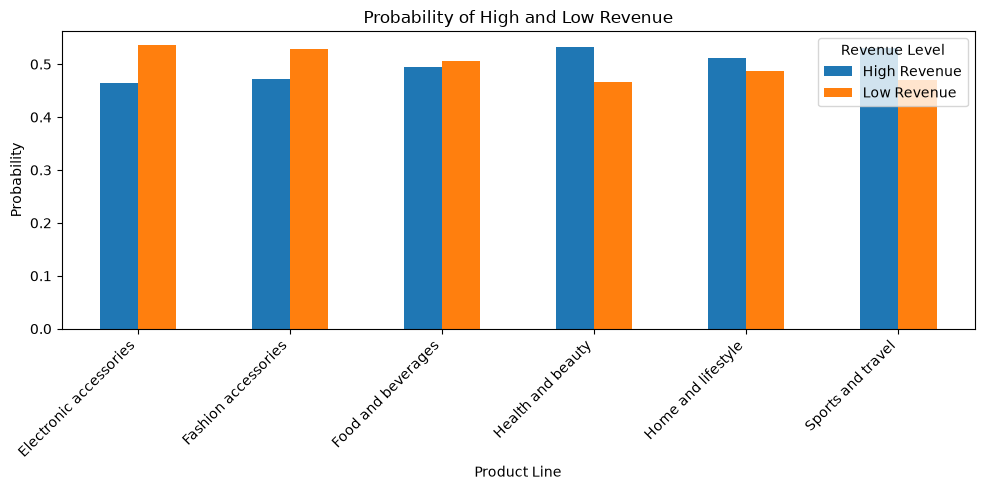


Highest Probability of High Revenue:
Health and beauty
Probability: 0.5329


In [ ]:
# Part A: Develop a Decision Tree Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load supermarket_sales.csv dataset
df = pd.read_csv("supermarket_sales.csv")

print("First 10 Records:")
print(df.head(10))

# 2. Display number of records, columns, column names and data types
print("\nNumber of Records:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

# 3. Display unique values of product_line
print("\nUnique Product Lines:")
print(df["product_line"].unique())

# 4. Calculate total revenue for each product line
total_revenue = df.groupby("product_line")["revenue"].sum()
print("\nTotal Revenue by Product Line:")
print(total_revenue)

# 5. Calculate average revenue for each product line
average_revenue = df.groupby("product_line")["revenue"].mean()
print("\nAverage Revenue by Product Line:")
print(average_revenue)

# 6. Calculate total quantity sold for each product line
total_quantity = df.groupby("product_line")["quantity"].sum()
print("\nTotal Quantity Sold by Product Line:")
print(total_quantity)

# 7. Calculate median value of revenue
median_revenue = df["revenue"].median()
print("\nMedian Revenue:", median_revenue)

# 8 & 9. Classify transactions as High Revenue or Low Revenue
df["revenue_level"] = np.where(
    df["revenue"] >= median_revenue,
    "High Revenue",
    "Low Revenue"
)
print("\nRevenue Classification:")
print(
    df[
        ["product_line", "revenue", "revenue_level"]
    ].head(10)
)

# 10. Calculate number of High and Low Revenue transactions
revenue_counts = pd.crosstab(
    df["product_line"],
    df["revenue_level"]
)
print("\nRevenue Counts:")
print(revenue_counts)

# 11. Calculate probability of High and Low Revenue
revenue_probabilities = pd.crosstab(
    df["product_line"],
    df["revenue_level"],
    normalize="index"
)
print("\nRevenue Probabilities:")
print(revenue_probabilities)

# 12. Verify that probabilities add up to 1
print("\nProbability Sum:")
print(revenue_probabilities.sum(axis=1))

# 13. Calculate average revenue for High and Low Revenue
payoffs = df.groupby(
    ["product_line", "revenue_level"]
)["revenue"].mean().unstack()
print("\nAverage Revenue / Payoff:")
print(payoffs)

# 14. Create Decision DataFrame
decision_df = revenue_probabilities.stack().reset_index()
decision_df.columns = [
    "Product Line",
    "Revenue Level",
    "Probability"
]
payoff_df = payoffs.stack().reset_index()
payoff_df.columns = [
    "Product Line",
    "Revenue Level",
    "Payoff"
]
decision_df = decision_df.merge(
    payoff_df,
    on=["Product Line", "Revenue Level"]
)
print("\nDecision DataFrame:")
print(decision_df)

# 15. Identify decision alternatives and uncertain outcomes
decision_alternatives = df["product_line"].unique()
uncertain_outcomes = df["revenue_level"].unique()
print("\nDecision Alternatives:")
print(decision_alternatives)
print("\nUncertain Outcomes:")
print(uncertain_outcomes)

# 16 & 17. Construct and display decision tree
print("\nDECISION TREE")
for product in decision_alternatives:
    print("\n" + product)
    print("   ├── High Revenue")
    p_high = revenue_probabilities.loc[
        product, "High Revenue"
    ]
    payoff_high = payoffs.loc[
        product, "High Revenue"
    ]
    print(
        "   │      Probability =",
        round(p_high, 4)
    )
    print(
        "   │      Payoff =",
        round(payoff_high, 2)
    )
    print("   └── Low Revenue")
    p_low = revenue_probabilities.loc[
        product, "Low Revenue"
    ]
    payoff_low = payoffs.loc[
        product, "Low Revenue"
    ]
    print(
        "          Probability =",
        round(p_low, 4)
    )
    print(
        "          Payoff =",
        round(payoff_low, 2)
    )
# 18. Visualization showing total revenue
plt.figure(figsize=(10, 5))
total_revenue.sort_values(
    ascending=False
).plot(kind="bar")
plt.title("Total Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# 19. Visualization showing High and Low Revenue probability
revenue_probabilities.plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Probability of High and Low Revenue")
plt.xlabel("Product Line")
plt.ylabel("Probability")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Revenue Level")
plt.tight_layout()
plt.show()
# 20. Identify product line with highest probability of High Revenue
highest_high_probability = revenue_probabilities[
    "High Revenue"
].idxmax()
highest_high_value = revenue_probabilities[
    "High Revenue"
].max()
print("\nHighest Probability of High Revenue:")
print(highest_high_probability)
print(
    "Probability:",
    round(highest_high_value, 4)
)

Expected Value helps a business select the
product line that provides the highest expected
financial return under uncertain outcomes.

Expected Value Formula:
EV = Σ (Probability × Payoff)

For two outcomes:
EV = (P(High) × Payoff(High)) +
     (P(Low) × Payoff(Low))

Expected Value of Home and lifestyle :
336.64

Expected Value of Every Product Line:
product_line
Electronic accessories    319.632538
Fashion accessories       305.089298
Food and beverages        322.671517
Health and beauty         323.643020
Home and lifestyle        336.636956
Sports and travel         332.065220
dtype: float64

Expected Value DataFrame:
             Product Line  High Revenue Probability  High Revenue Payoff  \
0  Electronic accessories                  0.464706           537.006152   
1     Fashion accessories                  0.471910           512.329375   
2      Food and beverages                  0.494253           515.127680   
3       Health and beauty                  0.532895           497

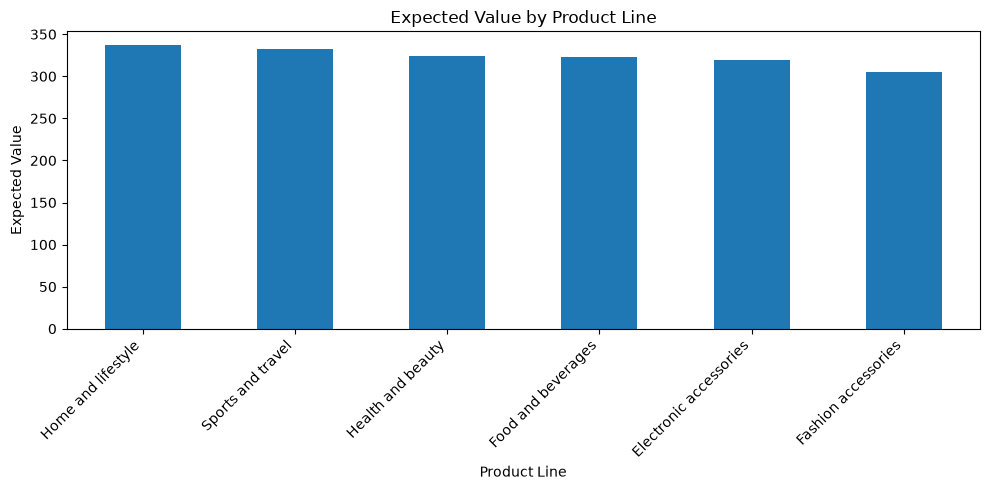


Comparison:
Highest High Revenue Probability: Health and beauty
Highest Expected Value: Home and lifestyle
They are different product lines.

After Changing Probability:
Product: Home and lifestyle
New High Revenue Probability: 0.7
New Low Revenue Probability: 0.30000000000000004
New Expected Value: 410.85

After Changing High Revenue Payoff:
New High Revenue Payoff: 629.58
New Expected Value: 387.89

FINAL DECISION
Selected Product Line: Home and lifestyle
Highest Expected Value: 336.64

FINAL DECISION TREE

Electronic accessories
  ├── High Revenue
  │   Probability: 0.4647
  │   Payoff: 537.01
  └── Low Revenue
      Probability: 0.5353
      Payoff: 130.92
  Expected Value: 319.63

Fashion accessories
  ├── High Revenue
  │   Probability: 0.4719
  │   Payoff: 512.33
  └── Low Revenue
      Probability: 0.5281
      Payoff: 119.9
  Expected Value: 305.09

Food and beverages
  ├── High Revenue
  │   Probability: 0.4943
  │   Payoff: 515.13
  └── Low Revenue
      Probability: 0.5057

In [4]:
# Part B: Apply Expected Value

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("supermarket_sales.csv")
# Calculate median revenue
median_revenue = df["revenue"].median()
# Classify revenue
df["revenue_level"] = np.where(
    df["revenue"] >= median_revenue,
    "High Revenue",
    "Low Revenue"
)
# Calculate probabilities
revenue_probabilities = pd.crosstab(
    df["product_line"],
    df["revenue_level"],
    normalize="index"
)
# Calculate payoffs
payoffs = df.groupby(
    ["product_line", "revenue_level"]
)["revenue"].mean().unstack()
# 21. Explain Expected Value
print("Expected Value helps a business select the")
print("product line that provides the highest expected")
print("financial return under uncertain outcomes.")
# 22. Expected Value Formula
print("\nExpected Value Formula:")
print("EV = Σ (Probability × Payoff)")
print("\nFor two outcomes:")
print("EV = (P(High) × Payoff(High)) +")
print("     (P(Low) × Payoff(Low))")
# 23. Calculate Expected Value of one product line
product = "Home and lifestyle"
high_probability = revenue_probabilities.loc[
    product, "High Revenue"
]
low_probability = revenue_probabilities.loc[
    product, "Low Revenue"
]
high_payoff = payoffs.loc[
    product, "High Revenue"
]
low_payoff = payoffs.loc[
    product, "Low Revenue"
]
one_product_ev = (
    high_probability * high_payoff
    +
    low_probability * low_payoff
)
print("\nExpected Value of", product, ":")
print(round(one_product_ev, 2))
# 24. Calculate Expected Value for every product line
expected_values = (
    revenue_probabilities * payoffs
).sum(axis=1)
print("\nExpected Value of Every Product Line:")
print(expected_values)
# 25. Create Expected Value DataFrame
ev_df = pd.DataFrame({
    "Product Line": revenue_probabilities.index,
    "High Revenue Probability":
        revenue_probabilities["High Revenue"].values,
    "High Revenue Payoff":
        payoffs["High Revenue"].values,
    "Low Revenue Probability":
        revenue_probabilities["Low Revenue"].values,
    "Low Revenue Payoff":
        payoffs["Low Revenue"].values,
    "Expected Value":
        expected_values.values
})
print("\nExpected Value DataFrame:")
print(ev_df)
# 26. Compare Expected Values
print("\nExpected Value Comparison:")
print(
    expected_values.sort_values(
        ascending=False
    )
)
# 27. Product line with highest Expected Value
highest_ev_product = expected_values.idxmax()
highest_ev = expected_values.max()
print("\nHighest Expected Value:")
print(highest_ev_product)
print(
    "Expected Value:",
    round(highest_ev, 2)
)
# 28. Product line with lowest Expected Value
lowest_ev_product = expected_values.idxmin()
lowest_ev = expected_values.min()

print("\nLowest Expected Value:")
print(lowest_ev_product)
print(
    "Expected Value:",
    round(lowest_ev, 2)
)
# 29. Rank product lines from highest to lowest Expected Value
ranking = expected_values.sort_values(
    ascending=False
).reset_index()
ranking.columns = [
    "Product Line",
    "Expected Value"
]
print("\nProduct Line Ranking:")
print(ranking)
# 30. Bar chart comparing Expected Values
plt.figure(figsize=(10, 5))
expected_values.sort_values(
    ascending=False
).plot(kind="bar")
plt.title("Expected Value by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Expected Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# 31 & 32. Compare highest High Revenue probability
highest_high_probability = revenue_probabilities[
    "High Revenue"
].idxmax()
print("\nComparison:")
print(
    "Highest High Revenue Probability:",
    highest_high_probability
)
print(
    "Highest Expected Value:",
    highest_ev_product
)
if highest_high_probability == highest_ev_product:
    print(
        "Both are the same product line."
    )
else:
    print(
        "They are different product lines."
    )
# 33. Change probability of one possible outcome
product = "Home and lifestyle"
new_high_probability = 0.70
new_low_probability = 1 - new_high_probability
new_ev_probability = (
    new_high_probability *
    payoffs.loc[
        product, "High Revenue"
    ]
    +
    new_low_probability *
    payoffs.loc[
        product, "Low Revenue"
    ]
)
print("\nAfter Changing Probability:")
print("Product:", product)
print(
    "New High Revenue Probability:",
    new_high_probability
)
print(
    "New Low Revenue Probability:",
    new_low_probability
)
print(
    "New Expected Value:",
    round(new_ev_probability, 2)
)
# 34. Change payoff of one possible outcome
new_high_payoff = (
    payoffs.loc[
        product, "High Revenue"
    ] + 100
)
new_ev_payoff = (
    revenue_probabilities.loc[
        product, "High Revenue"
    ]
    * new_high_payoff
    +
    revenue_probabilities.loc[
        product, "Low Revenue"
    ]
    * payoffs.loc[
        product, "Low Revenue"
    ]
)
print("\nAfter Changing High Revenue Payoff:")
print(
    "New High Revenue Payoff:",
    round(new_high_payoff, 2)
)
print(
    "New Expected Value:",
    round(new_ev_payoff, 2)
)
# 35. Automatically select product line
best_product = expected_values.idxmax()

print("\nFINAL DECISION")
print(
    "Selected Product Line:",
    best_product
)
print(
    "Highest Expected Value:",
    round(
        expected_values[best_product],
        2
    )
)
# 36. Display final decision tree with Expected Value
print("\nFINAL DECISION TREE")
for product in expected_values.index:
    print("\n" + product)
    print("  ├── High Revenue")
    print(
        "  │   Probability:",
        round(
            revenue_probabilities.loc[
                product,
                "High Revenue"
            ],
            4
        )
    )
    print(
        "  │   Payoff:",
        round(
            payoffs.loc[
                product,
                "High Revenue"
            ],
            2
        )
    )
    print("  └── Low Revenue")
    print(
        "      Probability:",
        round(
            revenue_probabilities.loc[
                product,
                "Low Revenue"
            ],
            4
        )
    )
    print(
        "      Payoff:",
        round(
            payoffs.loc[
                product,
                "Low Revenue"
            ],
            2
        )
    )
    print(
        "  Expected Value:",
        round(
            expected_values.loc[product],
            2
        )
    )
# 37. Business Recommendation
print("\nBUSINESS RECOMMENDATION")
print(
    "The business should select",
    best_product,
    "because it has the highest Expected Value of",
    round(
        expected_values[best_product],
        2
    )
)